In [1]:
# Import necessary libraries for data manipulation, visualization, and suppressing warnings.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the house price regression dataset into a pandas DataFrame.
df = pd.read_csv('house_price_regression_dataset.csv')

In [3]:
# Display the first 5 rows of the DataFrame to inspect the data.
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


The values like `2.623829e+05` are numbers in scientific notation. `e+05` means `* 10^5`. These are already numerical (float64) and don't need special treatment for calculations. If you prefer to display them without scientific notation, you can set Pandas display options:

In [4]:
# Set display options to prevent scientific notation for float numbers and display the first few rows again.
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Display the head again to see the effect
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.60,0,5,262382.85
1,4272,3,3,2016,4.75,1,6,985260.85
2,3592,1,2,2016,3.63,0,9,777977.39
3,966,1,2,1977,2.73,1,8,229698.92
4,4926,2,1,1993,4.70,0,8,1041740.86


In [5]:
# Display information about the DataFrame, including column data types and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [6]:
# Generate descriptive statistics of the numerical columns in the DataFrame.
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2815.42,2.99,1.97,1986.55,2.78,1.02,5.62,618861.02
std,1255.51,1.43,0.82,20.63,1.30,0.81,2.89,253568.06
min,503.00,1.00,1.00,1950.00,0.51,0.00,1.00,111626.85
25%,1749.50,2.00,1.00,1969.00,1.67,0.00,3.00,401648.23
50%,2862.50,3.00,2.00,1986.00,2.81,1.00,6.00,628267.29
75%,3849.50,4.00,3.00,2004.25,3.92,2.00,8.00,827141.28
max,4999.00,5.00,3.00,2022.00,4.99,2.00,10.00,1108236.84


In [7]:
# Check for any missing values in each column of the DataFrame.
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [8]:
# Check for any duplicate rows in the DataFrame.
df.duplicated().sum()

np.int64(0)

In [9]:
# Count the occurrences of each unique value in the 'Garage_Size' column.
df['Garage_Size'].value_counts()

,count
Garage_Size,
2,343
1,336
0,321


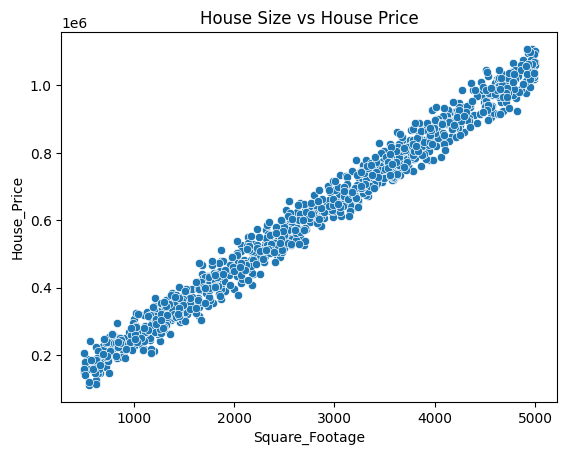

In [15]:
# Create a scatter plot to visualize the relationship between 'Square_Footage' and 'House_Price'.
sns.scatterplot(x='Square_Footage', y='House_Price', data=df)
plt.title('House Size vs House Price')
plt.show()

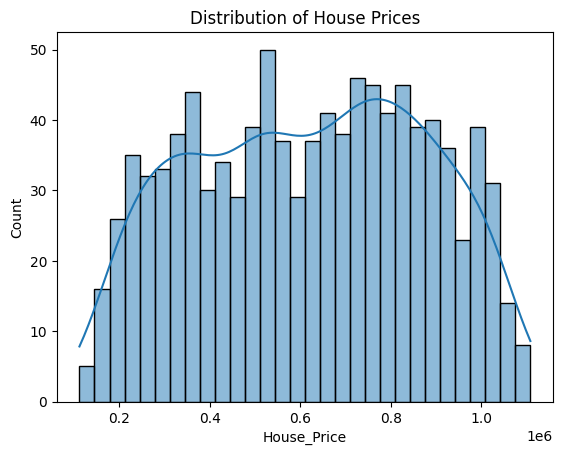

In [18]:
# Create a histogram to visualize the distribution of 'House_Price'.
sns.histplot(df['House_Price'], kde=True, bins = 30)
plt.title('Distribution of House Prices')
plt.show()

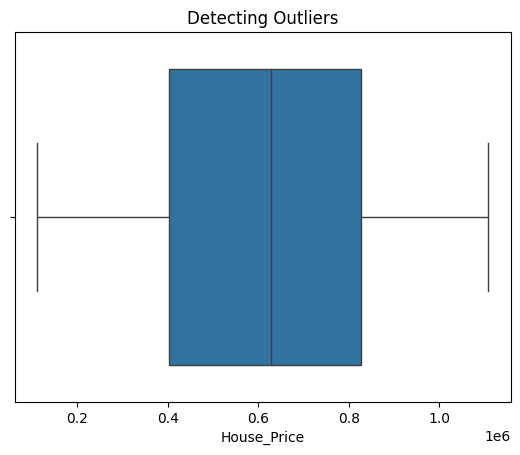

In [28]:
# Create a box plot to visualize the distribution of 'House_Price' and detect potential outliers.
sns.boxplot(x = 'House_Price', data = df)
plt.title('Detecting Outliers')
plt.show()

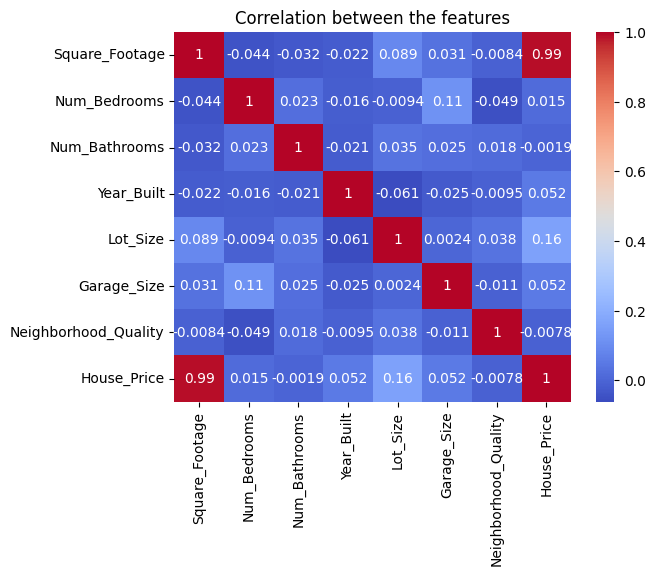

In [10]:
# Create a heatmap to visualize the correlation matrix between all numerical features.
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between the features")
plt.show()

In [11]:
# Separate the dataset into features (X) and the target variable (y).
X = df.drop('House_Price', axis = 1)
y = df['House_Price']

In [12]:
# Split the data into training and testing sets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Initialize a StandardScaler for feature scaling.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [14]:
# Scale the features of the training and testing sets.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Import the LinearRegression model from scikit-learn.
from sklearn.linear_model import LinearRegression

In [20]:
# Initialize the Linear Regression model.
model = LinearRegression()

In [21]:
# Train the Linear Regression model using the scaled training data.
model.fit(X_train_scaled, y_train)

LinearRegression()

In [23]:
# Make predictions on the scaled test data.
y_pred = model.predict(X_test_scaled)

In [24]:
# Import evaluation metrics for regression models.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
# Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) score.
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

In [26]:
# Print the calculated evaluation metrics.
print('MAE:', MAE)
print('MSE:', MSE)
print('RMSE:', RMSE)
print('R2:', R2)

MAE: 8174.583600006616
MSE: 101434798.50563587
RMSE: 10071.484424137083
R2: 0.9984263636823413
